# Dangerous Accessible Space / Expected Pass Completion

<b>Dangerous accessible space (DAS)</b> is a flavor of EPV (expected possession value) based on <b>physical pass simulations</b>. For every frame where a player is in possession, the model simulates multiple ground passes of that player with different speeds and angles, such that all possible directions are covered. Then it calculates the likelihood that each player can intercept a given pass at every position along its simulated trajectory. This likelihood can then be weighted by some measure of goal threat, aggregated by team, and integrated across the pitch to give a numerical value, describing the amount of dangerous space that is accessible in the current situation.

The formula to calculate the probability to intercept or receive the ball along a pass trajectory for a given player $r$ boils down to:

$$\frac{dP_r(t)}{dt} = P_0(t)a_r(t)$$

Where $\frac{dP_r(t)}{dt}$ is the probability density that player $r$ intercepts the ball at time $t$ along the pass trajectory, $P_0(t)$ is the probability that the ball has not been intercepted yet until time $t$ and $a_r(t)$ is the transition rate from $P_0(t)$ (not intercepted) to $P_r(t)$ (intercepted by $r$). The calculation of $a_r(t)$ is based on the difference between the arrival time of a player and the ball like this:

$$a_r(t) = \frac{1}{1 + e^{b_0 + b_1(T_r(t) - t)}}\frac{1}{\sigma(v_B(t))}$$

Where $b_0$ and $b_1$ are parameters, $T_r(t)$ is the arrival time of the player, $t$ is the arrival time of the ball and $\sigma(v_B(t))$ is a function that gives the model an additional factor that is dependent on the ball speed $v_B(t)$ to take into account that the ability to intercept varies with the speed of the ball. Essentially, this means that the earlier a player arrives relative the ball, the higher the transition rate $a_r(t)$ (and, accordingly, the interception probability density $\frac{dP_r(t)}{dt}$).

The other half of the formula, $P_0(t)$, is calculated based on the integral of the transition rates of all players up until time $t$. Intuitively, if a lot of players had high interception rates in the past, $P_0(t)$ will be small and diminish all $\frac{dP_r(t)}{dt}$ values further down the trajectory. In other words, the likelihood of interception is low if the pass has likely been intercepted before, even if the current interception rate is high. 

$$P_0(t) = e^{\int_{0}^{t}(-\sum_{r \in R}^{}a_r(\tau))d\tau}$$

By aggregating and plotting the resulting interception probability densities $\frac{dP_r(t)}{dt}$ spatially, we obtain the <b>accessible space</b> field (top image) of a team. If we add a notion of value like Expected Goals we obtain <b>dangerous accessible space</b> (bottom image) whose area integral serves as our final metric, DAS.



![Accessible space](../static/accessible_space.png)
![Dangerous accessible space](../static/dangerous_accessible_space.png)



This is the gist of DAS and the physical pass simulations behind it. More details and explanations can be found in the publication of the model by Bischofberger and Baca (2025)$^1$ and the corresponding repository$^2$.

In databallpy, we can use the ``add_dangerous_accessible_space`` function to access team-level DAS for every frame of tracking data.

---

$^1$ Bischofberger, J., & Baca, A. (2025). Dangerous accessible space: A unified model of space and value in team sports [Preprint]. Research Square. https://doi.org/10.21203/rs.3.rs-6932689/v1

$^2$ https://github.com/jonas-bischofberger/accessible-space

In [3]:
from databallpy import get_saved_game, get_open_game
import os
import pandas as pd

# game = get_open_game(provider="metrica")
game = get_saved_game("open_metrica", os.path.join(os.getcwd(), "../saved_games"))
if not "dangerous_accessible_space" in game.tracking_data.columns.to_list():
    game.synchronise_tracking_and_event_data(verbose=False)
    game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], filter_type="savitzky_golay")
    game.tracking_data.add_individual_player_possession()
    game.tracking_data.add_team_possession(game.event_data, game.home_team_id)
    # Add mask as argument since it can take minutes to compute it for the full match
    mask = (~pd.isnull(game.tracking_data["player_possession"])) & (game.tracking_data.index <= 1300)

    game.tracking_data.add_dangerous_accessible_space(mask)

    v_cols = [x for x in game.tracking_data.columns if x.endswith("_vx") or x.endswith("_vy") or x.endswith(")velocity")]
    game.tracking_data.drop(columns=v_cols, inplace=True)
    game.save_game("open_metrica", os.path.join(os.getcwd(), "../saved_games"), allow_overwrite=True, verbose=False)

game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], filter_type="savitzky_golay")

```python
from databallpy import get_open_game
import os

game = get_open_game(provider="metrica")
game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], filter_type="savitzky_golay")

game.tracking_data.add_individual_player_possession()
game.synchronise_tracking_and_event_data()
game.tracking_data.add_team_possession(game.event_data, game.home_team_id)

# Add mask as argument since it can take minutes to compute it for the full match
    mask = (~pd.isnull(game.tracking_data["player_possession"])) & (game.tracking_data.index <= 1300)
game.tracking_data.add_dangerous_accessible_space(mask)

print(game.tracking_data[
    ["period_id", "frame", "team_possession", "event_id", "dangerous_accessible_space"]
].dropna()
)

```


In [4]:
game.tracking_data[
    ["period_id", "frame", "team_possession", "event_id", "dangerous_accessible_space"]
].dropna().head()

,period_id,frame,team_possession,event_id,dangerous_accessible_space
365,1,366,home,-999,0.137242
366,1,367,home,-999,0.135923
367,1,368,home,-999,0.135279
368,1,369,home,-999,0.135522
369,1,370,home,-999,0.135579


Plotting DAS of both teams in a line graph highlights how the possession phases of the teams unfold during the game.

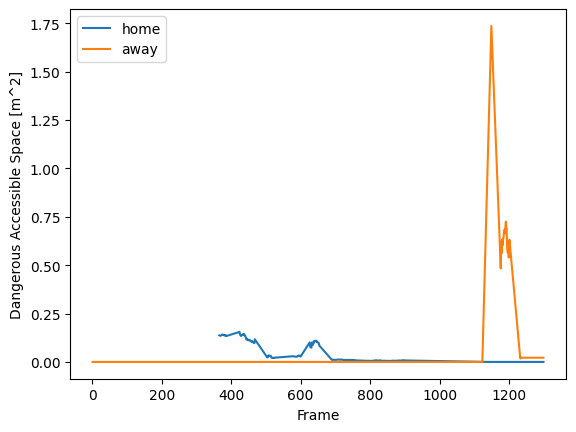

In [5]:
import matplotlib.pyplot as plt

df = game.tracking_data[game.tracking_data["frame"] < 1300].copy()  # Example slice

plt.figure()
plt.xlabel("Frame")
plt.ylabel("Dangerous Accessible Space [m^2]")
for team in game.tracking_data["team_possession"].dropna().unique():
    dfx = df.copy()
    i_team_possession = dfx["team_possession"] == team
    dfx.loc[~i_team_possession, "dangerous_accessible_space"] = (
        0.0  # set DAS to 0 while the opponent or no one controls the ball
    )
    dfx["dangerous_accessible_space"] = dfx["dangerous_accessible_space"].interpolate(method="linear")
    plt.plot(dfx["frame"].to_numpy(), dfx["dangerous_accessible_space"].to_numpy(), label=f"{team}")

plt.legend()
plt.show()

The plot shows a relatively harmless attack by the home team in the beginning, followed by a short period of danger from the away team, possibly through a ball win or a set piece.

Aggregated DAS for each team gives us a summary of their threat during the match. In the table, we can see that the home team had higher total DAS values while the away team had higher DAS values on average, pointing to a style of play more focused on counterattacking or set pieces.

In [6]:
dfx[dfx["dangerous_accessible_space"] > 1.5]

,frame,ball_x,ball_y,ball_z,ball_status,team_possession,home_11_x,home_11_y,home_1_x,home_1_y,...,away_32_vx,away_32_vy,away_33_vx,away_33_vy,away_34_vx,away_34_vy,away_35_vx,away_35_vy,ball_vx,ball_vy
1145,1146,-15.62820,28.45528,NaN,alive,away,-41.35425,4.78040,-25.41315,32.14564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.389375,-7.605071
1146,1147,-15.90540,28.16832,NaN,alive,away,-41.37525,4.79128,-25.43940,32.13612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.271250,-7.499833
1147,1148,-16.18155,27.88068,NaN,alive,away,-41.39835,4.80216,-25.46250,32.11572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.054375,-5.545238
1148,1149,-16.45770,27.59372,NaN,alive,away,-41.41935,4.81236,-25.48035,32.09668,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.397500,-2.320500
1149,1150,-16.33170,27.66104,NaN,alive,away,-41.44455,4.82936,-25.49505,32.07832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.496250,1.113500
1150,1151,-16.10490,27.81812,NaN,alive,away,-41.47185,4.84568,-25.50975,32.06064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.429375,3.703167
1151,1152,-15.87810,27.97452,NaN,alive,away,-41.49810,4.86132,-25.51815,32.04228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.207500,4.392071
1152,1153,-15.65130,28.13092,NaN,alive,away,-41.52435,4.87492,-25.52340,32.01032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.790625,4.020905
1153,1154,-15.42450,28.28800,NaN,alive,away,-41.55060,4.88716,-25.52550,31.97632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.675625,3.914857


In [7]:
dfg = game.tracking_data.groupby("team_possession").agg(
    total_das=("dangerous_accessible_space", "sum"),
    max_das=("dangerous_accessible_space", "max"),
    mean_das=("dangerous_accessible_space", "mean"),
)
dfg["total_das"] /= (
    game.tracking_data.frame_rate
)  # divide by frame rate as normalization
dfg

,total_das,max_das,mean_das
team_possession,,,
away,0.720706,1.736167,0.600588
home,0.558041,0.155625,0.046349


Internally, ``databallpy`` calls functions from the ``accessible-space`` package. That package supports additional analyses, for example, you can obtain player-level DAS values as follows:

In [8]:
import accessible_space

df_long = game.tracking_data[game.tracking_data["frame"].between(1140, 1160)].to_long_format()
df_long["team"] = df_long["column_id"].str[:4]

res = accessible_space.get_individual_dangerous_accessible_space(
    df_long,
    frame_col="frame",
    period_col="period_id",
    player_col="column_id",
    team_col="team",
    x_col="x",
    y_col="y",
    vx_col="vx",
    vy_col="vy",
    team_in_possession_col="team_possession",
    player_in_possession_col="player_possession",
)
df_long["AS_player"] = res.player_acc_space
df_long["DAS_player"] = res.player_das
df_long[
    ["frame", "column_id", "team", "team_possession", "AS_player", "DAS_player"]
].dropna().drop_duplicates().head(20)

Simulating passes: 100%|██████████| 1/1 [00:00<00:00,  1.70chunk/s]


,frame,column_id,team,team_possession,AS_player,DAS_player
21,1140,home_11,home,away,67.142936,8.686584
22,1141,home_11,home,away,54.339316,6.986487
23,1142,home_11,home,away,54.991457,6.576475
24,1143,home_11,home,away,65.952619,7.720804
25,1144,home_11,home,away,102.813844,13.795594
26,1145,home_11,home,away,113.106561,15.531029
27,1146,home_11,home,away,115.191381,19.714295
28,1147,home_11,home,away,144.760435,23.057701
29,1148,home_11,home,away,136.795892,16.664871
30,1149,home_11,home,away,141.727886,17.155899


DAS can be visualized using the ``plot_expected_completion_surface`` function

Simulating passes: 100%|██████████| 1/1 [00:00<00:00,  3.22chunk/s]


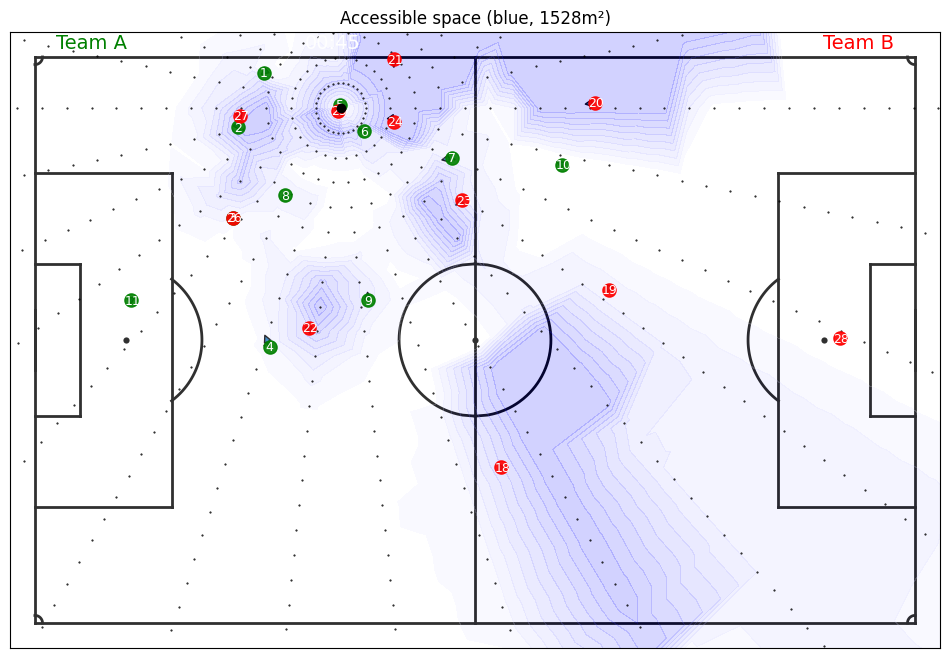

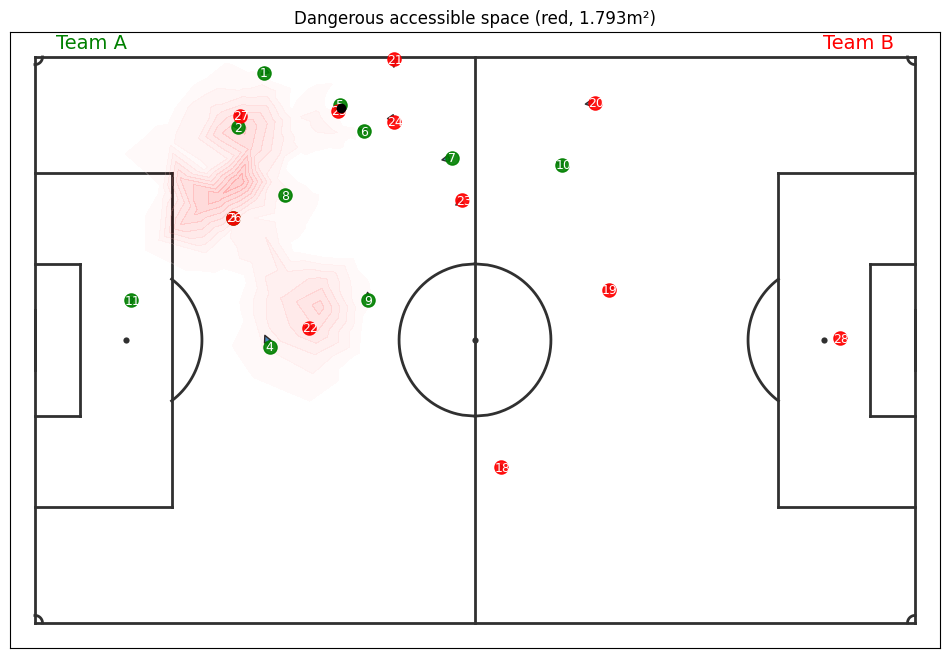

In [9]:
from databallpy.visualize import plot_soccer_pitch, plot_tracking_data

frame_to_plot = 1148

df_tracking_frame = df_long[df_long["frame"] == frame_to_plot]

das = accessible_space.get_dangerous_accessible_space(
    df_tracking_frame,
    frame_col="frame",
    period_col="period_id",
    player_col="column_id",
    team_col="team",
    x_col="x",
    y_col="y",
    vx_col="vx",
    vy_col="vy",
    team_in_possession_col="team_possession",
    player_in_possession_col="player_possession",
)

fig, ax = plot_soccer_pitch(pitch_color="white")
fig, ax = plot_tracking_data(
    game,
    game.tracking_data[game.tracking_data["frame"] == frame_to_plot].index[0],
    fig=fig,
    ax=ax,
    title=f"Accessible space (blue, {das.acc_space.iloc[0]:.0f}m²)",
    add_velocities=True,
)

fig = accessible_space.plot_expected_completion_surface(
    das.simulation_result,  # AS
    frame_index=0,
    color="blue",
)

fig, ax = plot_soccer_pitch(pitch_color="white")
fig, ax = plot_tracking_data(
    game,
    game.tracking_data[game.tracking_data["frame"] == frame_to_plot].index[0],
    fig=fig,
    ax=ax,
    title=f"Dangerous accessible space (red, {das.das.iloc[0]:.3f}m²)",
    add_velocities=True,
)
fig = accessible_space.plot_expected_completion_surface(
    das.dangerous_result,  # DAS
    frame_index=0,
    color="red",
    plot_gridpoints=False
)

This is the moment of the high danger moment for the away team we plotted over time earlier. The striker (red 26) is at the exact same location of the defender and is therefore onside, but barely visible in the plot. If the away team is able to get the ball to him, the away team has high chances of getting ball possession at a dangerous location on the pitch, hence dangerous accessible space. 

If you look at it, you might want to add some extra filters, for example, only determine the dangerous accessible space when the player is not pressured too much (have you seen the [pressure feature](https://databallpy.readthedocs.io/en/latest/features/pressure_page.html) in databallpy yet?)


For more information and excelent docs on the feature, please seethe Github repository of ``accessible-space``.$^2$